In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Лаги (lag features)

In [5]:
# Создаём пример временного ряда
data = {
    'Date': pd.to_datetime(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05', '2024-01-06']),
    'Price': [100.0, 101.0, 102.0, 105.0, 104.0, 106.0]
}
df = pd.DataFrame(data).set_index('Date')

# Создаём лагированный признак: цена предыдущего дня (Price_lag_1)
# shift(1) сдвигает весь столбец на 1 строку вниз.
df['Price_lag_1'] = df['Price'].shift(1)

print("Пример с лагом 1:")
print(df)

Пример с лагом 1:
            Price  Price_lag_1
Date                          
2024-01-01  100.0          NaN
2024-01-02  101.0        100.0
2024-01-03  102.0        101.0
2024-01-04  105.0        102.0
2024-01-05  104.0        105.0
2024-01-06  106.0        104.0


### Скользящие окна (rolling features)

In [6]:
# 1. Скользящее среднее за 3 дня (краткосрочный тренд)
# rolling(3).mean() — расчёт среднего за окно 3
# .shift(1) — сдвиг на 1 день для исторической корректности
df['Price_Rolling_Mean_3'] = df['Price'].rolling(window=3).mean().shift(1)

# 2. Скользящее стандартное отклонение за 5 дней (волатильность)
df['Price_Rolling_Std_5'] = df['Price'].rolling(window=5).std().shift(1)

print(df)

            Price  Price_lag_1  Price_Rolling_Mean_3  Price_Rolling_Std_5
Date                                                                     
2024-01-01  100.0          NaN                   NaN                  NaN
2024-01-02  101.0        100.0                   NaN                  NaN
2024-01-03  102.0        101.0                   NaN                  NaN
2024-01-04  105.0        102.0            101.000000                  NaN
2024-01-05  104.0        105.0            102.666667                  NaN
2024-01-06  106.0        104.0            103.666667             2.073644


### Кумулятивные признаки (Expanding)

In [7]:
# 1. Кумулятивное среднее (средняя цена за всю историю до текущего момента)
# expanding().mean() — расчёт среднего на всём доступном историческом окне
# .shift(1) — сдвиг на 1 день для предотвращения утечки
df['Price_Expanding_Mean'] = df['Price'].expanding().mean().shift(1)

# 2. Кумулятивный максимум (самая высокая цена за всю историю до текущего момента)
df['Price_Expanding_Max'] = df['Price'].expanding().max().shift(1)

print(df)

            Price  Price_lag_1  Price_Rolling_Mean_3  Price_Rolling_Std_5  \
Date                                                                        
2024-01-01  100.0          NaN                   NaN                  NaN   
2024-01-02  101.0        100.0                   NaN                  NaN   
2024-01-03  102.0        101.0                   NaN                  NaN   
2024-01-04  105.0        102.0            101.000000                  NaN   
2024-01-05  104.0        105.0            102.666667                  NaN   
2024-01-06  106.0        104.0            103.666667             2.073644   

            Price_Expanding_Mean  Price_Expanding_Max  
Date                                                   
2024-01-01                   NaN                  NaN  
2024-01-02                 100.0                100.0  
2024-01-03                 100.5                101.0  
2024-01-04                 101.0                102.0  
2024-01-05                 102.0               

### Задача 1. Создание лагированных признаков ( .shift(k) )

In [8]:
# Загрузка датасета
tesla_df = pd.read_csv('https://code.s3.yandex.net/datasets/tesla_historic_prices.csv')

In [9]:
# 1. Создадите Лаг 1 дня (цена закрытия предыдущего дня)
# P(T-1)
tesla_df['Close_Lag_1'] = tesla_df['Close'].shift(1)

# 2. Создадите Лаг 5 дней (цена закрытия неделю назад)
# P(T-5)
tesla_df['Close_Lag_5'] = tesla_df['Close'].shift(5)

print(tesla_df[['Close', 'Close_Lag_1', 'Close_Lag_5']].head(7))

      Close  Close_Lag_1  Close_Lag_5
0  1.592667          NaN          NaN
1  1.588667     1.592667          NaN
2  1.464000     1.588667          NaN
3  1.280000     1.464000          NaN
4  1.074000     1.280000          NaN
5  1.053333     1.074000     1.592667
6  1.164000     1.053333     1.588667


### Задача 2. Создание скользящих признаков (.rolling(N) .agg() .shift(1))

In [11]:
# 1. Создайте скользящее среднее за 20 дней
tesla_df['Close_Rolling_Mean_20'] = tesla_df['Close'].rolling(window=20).mean().shift(1)

# 2. Создайте Скользящее стандартное отклонение за 5 дней (волатильность)
tesla_df['Close_Rolling_Std_5'] = tesla_df['Close'].rolling(window=5).std().shift(1)

print(tesla_df[['Close', 'Close_Rolling_Mean_20', 'Close_Rolling_Std_5']].tail(5))

           Close  Close_Rolling_Mean_20  Close_Rolling_Std_5
3342  259.670013             258.291000             6.568608
3343  263.619995             257.595502             6.206652
3344  262.989990             257.402501             1.563816
3345  258.869995             256.987001             1.804495
3346  251.119995             256.128500             2.077176


### Задача 3. Создание кумулятивных признаков ( .expanding().agg().shift(1) )

In [12]:
# 1. Создайте кумулятивное среднее цены закрытия
tesla_df['Close_Expanding_Mean'] = tesla_df['Close'].expanding().mean().shift(1)

print(tesla_df[['Close', 'Close_Expanding_Mean']].tail(5))

           Close  Close_Expanding_Mean
3342  259.670013             67.600213
3343  263.619995             67.657667
3344  262.989990             67.716268
3345  258.869995             67.774646
3346  251.119995             67.831758


## Финальное обучение

### Создание лагов

In [13]:
# --- Загрузка данных и создание базовых лагов ---

# Сначала создаём базовые лагированные признаки
# Эти лаги зависят только от прошлых известных цен.
tesla_df['Close_Lag_1'] = tesla_df['Close'].shift(1)
tesla_df['Close_Lag_5'] = tesla_df['Close'].shift(5)

In [14]:
# --- Определяем столбцы ---
BASE_FEATURE_COLS = ['Open', 'Volume', 'Close_Lag_1', 'Close_Lag_5'] 
TARGET_COL = 'Close'
# Это признаки, которые будут созданы внутри цикла CV:
AGGREGATE_FEATURE_COLS = ['Close_Rolling_Mean_20', 'Close_Rolling_Std_5', 'Close_Expanding_Mean']
ALL_FEATURE_COLS = BASE_FEATURE_COLS + AGGREGATE_FEATURE_COLS

In [15]:
# --- Удаление строк с NaN ---
initial_rows = len(tesla_df)
# Мы удаляем строки с NaN, возникшие из-за базовых лагов
tesla_df_cleaned = tesla_df.dropna(subset=BASE_FEATURE_COLS + [TARGET_COL])
rows_removed = initial_rows - len(tesla_df_cleaned)

In [16]:
# --- Разделение на X/Y и OOT-тест ---
oot_size = 252
X_full = tesla_df_cleaned[BASE_FEATURE_COLS]
y_full = tesla_df_cleaned[TARGET_COL]

X_train_val_base = X_full[:-oot_size]
y_train_val = y_full[:-oot_size]
X_oot_base = X_full[-oot_size:]
y_oot = y_full[-oot_size:]
df_oot = tesla_df_cleaned.iloc[-oot_size:] # Для вывода даты

print(f"Размер обучающей/валидационной выборки: {X_train_val_base.shape}")

Размер обучающей/валидационной выборки: (3090, 4)


### Функция для корректного расчёта Rolling/Expanding

In [40]:
def create_aggregate_features(df_segment):
    """Рассчитывает Rolling/Expanding-признаки ТОЛЬКО на переданном сегменте."""
    
    close = df_segment[TARGET_COL] 
    
    # 1. Rolling Mean 20
    df_segment['Close_Rolling_Mean_20'] = close.rolling(window=20).mean().shift(1)
    
    # 2. Rolling Std 5
    df_segment['Close_Rolling_Std_5'] = close.rolling(window=5).std().shift(1)
    
    # 3. Expanding Mean
    df_segment['Close_Expanding_Mean'] = close.expanding().mean().shift(1)
    
    return df_segment

# Добавляем новые признаки в список
AGGREGATE_FEATURE_COLS = ['Close_Rolling_Mean_20', 'Close_Rolling_Std_5', 'Close_Expanding_Mean']
ALL_FEATURE_COLS = BASE_FEATURE_COLS + AGGREGATE_FEATURE_COLS 

### Цикл кросс-валидации (CV)

In [41]:
# --- Инициализация ---
tscv = TimeSeriesSplit(n_splits=5) 
mae_scores = []

# --- Пайплайн (MinMaxScaler предотвращает утечку масштабирования) ---
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', LinearRegression())
])

# --- ГЛАВНЫЙ ЦИКЛ КРОСС-ВАЛИДАЦИИ (Соблюдение State Leakage) ---
for fold, (train_index, val_index) in enumerate(tscv.split(X_train_val_base), 1):
    # Разделение Train/Val сегментов
    X_train_base_fold, X_val_base_fold = X_train_val_base.iloc[train_index], X_train_val_base.iloc[val_index]
    y_train_fold, y_val_fold = y_train_val.iloc[train_index], y_train_val.iloc[val_index]
    
    # Печатаем индексы
    print(f"\nФолд {fold}")
    print(f"Train indices: {train_index[0]}-{train_index[-1]} (total {len(train_index)})")
    print(f"Val indices:   {val_index[0]}-{val_index[-1]} (total {len(val_index)})")
    
    # 1. Train-фолд
    # Формируем DataFrame для Train-фолда (для расчёта Rolling/Expanding)
    df_train_cv = pd.concat([X_train_base_fold, y_train_fold.rename(TARGET_COL)], axis=1)
    # Создание признаков только на Train-фолде
    df_train_engineered = create_aggregate_features(df_train_cv.copy())
    df_train_engineered.dropna(inplace=True)
    
    X_train_final = df_train_engineered[ALL_FEATURE_COLS].values
    y_train_final = df_train_engineered[TARGET_COL].values
    
    # 2. Val-фолд (объединяем для корректных агрегатов)
    # Объединяем Train и Val, рассчитываем агрегаты на объединённом DF, берём только Val-часть
    df_val_full = pd.concat([df_train_cv, X_val_base_fold.join(y_val_fold.rename(TARGET_COL))], axis=0)
    df_val_engineered = create_aggregate_features(df_val_full.copy())
    
    df_val_fold_final = df_val_engineered.iloc[len(df_train_cv):]
    df_val_fold_final = df_val_fold_final.dropna(subset=ALL_FEATURE_COLS + [TARGET_COL])
    
    X_val_final = df_val_fold_final[ALL_FEATURE_COLS].values
    y_val_final = df_val_fold_final[TARGET_COL].values
    
    # 4. Обучение и оценка
    pipeline.fit(X_train_final, y_train_final)
    y_pred_val = pipeline.predict(X_val_final)
    
    mae_scores.append(mean_absolute_error(y_val_final, y_pred_val))


avg_mae = np.mean(mae_scores)


Фолд 1
Train indices: 0-514 (total 515)
Val indices:   515-1029 (total 515)

Фолд 2
Train indices: 0-1029 (total 1030)
Val indices:   1030-1544 (total 515)

Фолд 3
Train indices: 0-1544 (total 1545)
Val indices:   1545-2059 (total 515)

Фолд 4
Train indices: 0-2059 (total 2060)
Val indices:   2060-2574 (total 515)

Фолд 5
Train indices: 0-2574 (total 2575)
Val indices:   2575-3089 (total 515)



--- Результаты TimeSeriesSplit по фолдам ---
Фолд 1: MAE = 0.1948
Фолд 2: MAE = 0.3073
Фолд 3: MAE = 0.3336
Фолд 4: MAE = 1.0633
Фолд 5: MAE = 6.5136

Средняя MAE по всем фолдам: 1.6825


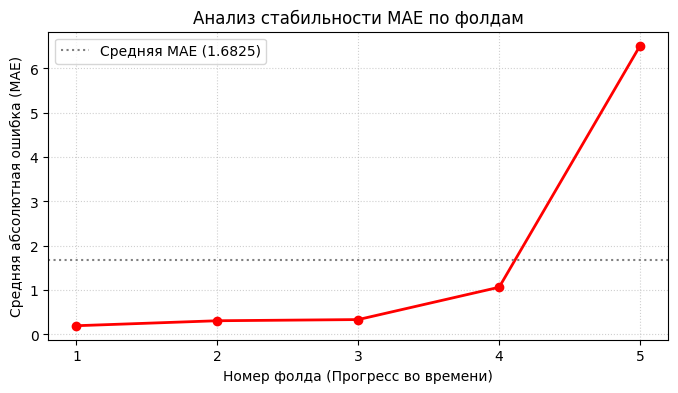

In [42]:
# --- АНАЛИЗ СТАБИЛЬНОСТИ МЕТРИК ---
print("\n--- Результаты TimeSeriesSplit по фолдам ---")
for i, mae in enumerate(mae_scores):
    print(f"Фолд {i+1}: MAE = {mae:.4f}")

avg_mae = np.mean(mae_scores)
print(f"\nСредняя MAE по всем фолдам: {avg_mae:.4f}")

# Визуализация стабильности
fold_numbers = np.arange(1, len(mae_scores) + 1)
plt.figure(figsize=(8, 4))
plt.plot(fold_numbers, mae_scores, marker='o', color='red', linewidth=2)
plt.axhline(y=avg_mae, color='gray', linestyle=':', label=f'Средняя MAE ({avg_mae:.4f})')
plt.title('Анализ стабильности MAE по фолдам')
plt.xlabel('Номер фолда (Прогресс во времени)')
plt.ylabel('Средняя абсолютная ошибка (MAE)')
plt.xticks(fold_numbers)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Финальное обучение и оценка на ООТ-тесте

In [43]:
# Обучение финальной модели на всём Train/Val-наборе
df_final_train_full = pd.concat([X_train_val_base, y_train_val.rename(TARGET_COL)], axis=1)
df_train_final_engineered = create_aggregate_features(df_final_train_full.copy())
df_train_final_engineered.dropna(inplace=True)
X_train_final_full = df_train_final_engineered[ALL_FEATURE_COLS].values
y_train_final_full = df_train_final_engineered[TARGET_COL].values

final_pipeline = Pipeline([('scaler', MinMaxScaler()), ('regressor', LinearRegression())])
final_pipeline.fit(X_train_final_full, y_train_final_full)

# Подготовка OOT-теста (продолжение агрегации с конца Train)
df_oot_full_sequence = pd.concat([df_final_train_full, X_oot_base.join(y_oot.rename(TARGET_COL))], axis=0)
df_oot_engineered = create_aggregate_features(df_oot_full_sequence.copy())

X_oot_final = df_oot_engineered.iloc[len(df_final_train_full):][ALL_FEATURE_COLS].values
y_oot_final = y_oot.values 

# Прогнозирование и вывод метрик
y_pred_oot = final_pipeline.predict(X_oot_final)

mae_oot = mean_absolute_error(y_oot_final, y_pred_oot)
mse_oot = mean_squared_error(y_oot_final, y_pred_oot)
rmse_oot = np.sqrt(mse_oot)
r2_oot = r2_score(y_oot_final, y_pred_oot)

print(f"\n--- ФИНАЛЬНАЯ ОЦЕНКА НА OOT-ТЕСТЕ ({len(X_oot_final)} ДНЕЙ) ---")
print(f"Период OOT: с {df_oot['Date'].iloc[0]} по {df_oot['Date'].iloc[-1]}")
print("-" * 50)
print(f"1. MAE (Средняя абс. ошибка): {mae_oot:.4f}")
print(f"2. RMSE (Корень из MSE): {rmse_oot:.4f}")
print(f"3. R² (Коэфф. детерминации): {r2_oot:.4f} (Объясняющая сила)")
print("-" * 50)


--- ФИНАЛЬНАЯ ОЦЕНКА НА OOT-ТЕСТЕ (252 ДНЕЙ) ---
Период OOT: с 2022-10-13 по 2023-10-13
--------------------------------------------------
1. MAE (Средняя абс. ошибка): 4.9086
2. RMSE (Корень из MSE): 6.3034
3. R² (Коэфф. детерминации): 0.9800 (Объясняющая сила)
--------------------------------------------------


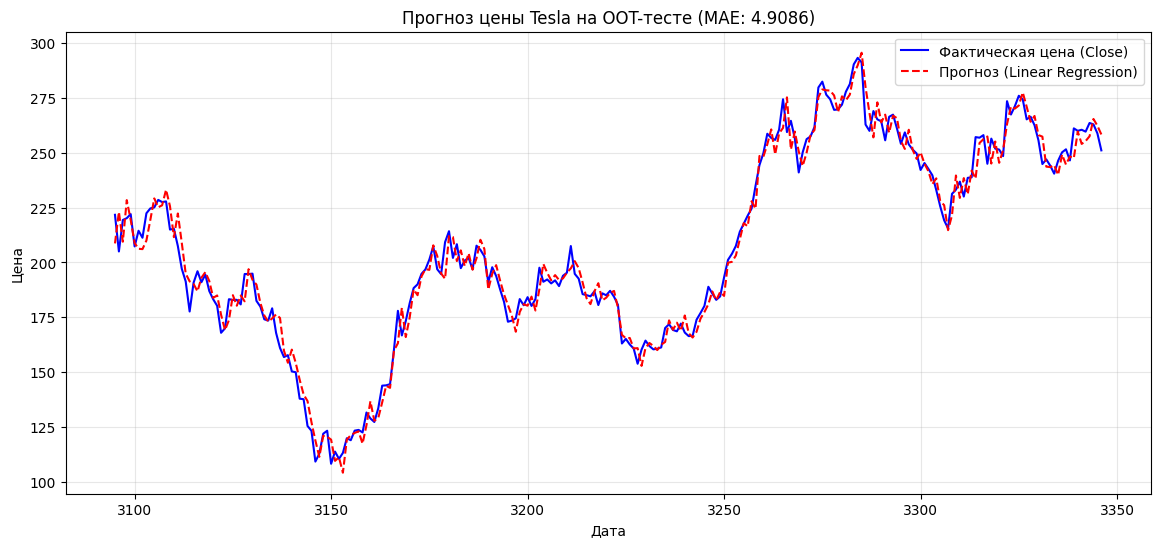

In [44]:
# Визуализация
plt.figure(figsize=(14, 6))
plt.plot(df_oot_engineered.index[len(df_final_train_full):], y_oot_final, label='Фактическая цена (Close)', color='blue')
plt.plot(df_oot_engineered.index[len(df_final_train_full):], y_pred_oot, label='Прогноз (Linear Regression)', color='red', linestyle='--')
plt.title(f'Прогноз цены Tesla на OOT-тесте (MAE: {mae_oot:.4f})')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()